# MSE 5720 Assignment 2  
**Haichuan Zhang**  
📧 *hz738@cornell.edu*  

##### All shell scripts, original input files, and output files can be found in the GitHub repository: https://github.com/chemerzhc/Cornell-MSE5720-Assignment.
---

## Introduction  



In [1]:
import os
import re
import requests
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [46]:
base_path = "HW1/Q1/A"
cutoffs = list(range(20, 101, 10))  # 20, 30, ..., 100
print(cutoffs)
energies = []
energy_pattern = re.compile(r"[! ]\s*total energy\s*=\s*(-?\d+\.\d+)")

[20, 30, 40, 50, 60, 70, 80, 90, 100]


In [47]:
for cutoff in cutoffs:
    url = (
        f"https://raw.githubusercontent.com/"
        f"chemerzhc/Cornell-MSE5720-Assignment/"
        f"main/HW2/Q1/A_Pre_Cal/energycutoff/si_{cutoff}/Si_{cutoff}.out"
    )

    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        energies.append(None)
        continue

    content = response.text
    match = energy_pattern.search(content)
    if match:
        energy = float(match.group(1))
        energies.append(energy)
        print(f"Cutoff {cutoff}: Energy = {energy:.8f} Ry")
    else:
        print(f"⚠️ No energy found in {url}")
        energies.append(None)

print("\nEnergies collected:")
for cutoff, energy in zip(cutoffs, energies):
    print(f"ecutwfc = {cutoff} Ry → total energy = {energy}")

Cutoff 20: Energy = -19.25618939 Ry
Cutoff 30: Energy = -19.25687729 Ry
Cutoff 40: Energy = -19.25699355 Ry
Cutoff 50: Energy = -19.25702285 Ry
Cutoff 60: Energy = -19.25704498 Ry
Cutoff 70: Energy = -19.25705342 Ry
Cutoff 80: Energy = -19.25706924 Ry
Cutoff 90: Energy = -19.25708139 Ry
Cutoff 100: Energy = -19.25708212 Ry

Energies collected:
ecutwfc = 20 Ry → total energy = -19.25618939
ecutwfc = 30 Ry → total energy = -19.25687729
ecutwfc = 40 Ry → total energy = -19.25699355
ecutwfc = 50 Ry → total energy = -19.25702285
ecutwfc = 60 Ry → total energy = -19.25704498
ecutwfc = 70 Ry → total energy = -19.25705342
ecutwfc = 80 Ry → total energy = -19.25706924
ecutwfc = 90 Ry → total energy = -19.25708139
ecutwfc = 100 Ry → total energy = -19.25708212


cutoffs: 9 [20, 30, 40, 50, 60, 70, 80, 90, 100]
energies: 9 [-19.25618939, -19.25687729, -19.25699355, -19.25702285, -19.25704498, -19.25705342, -19.25706924, -19.25708139, -19.25708212]


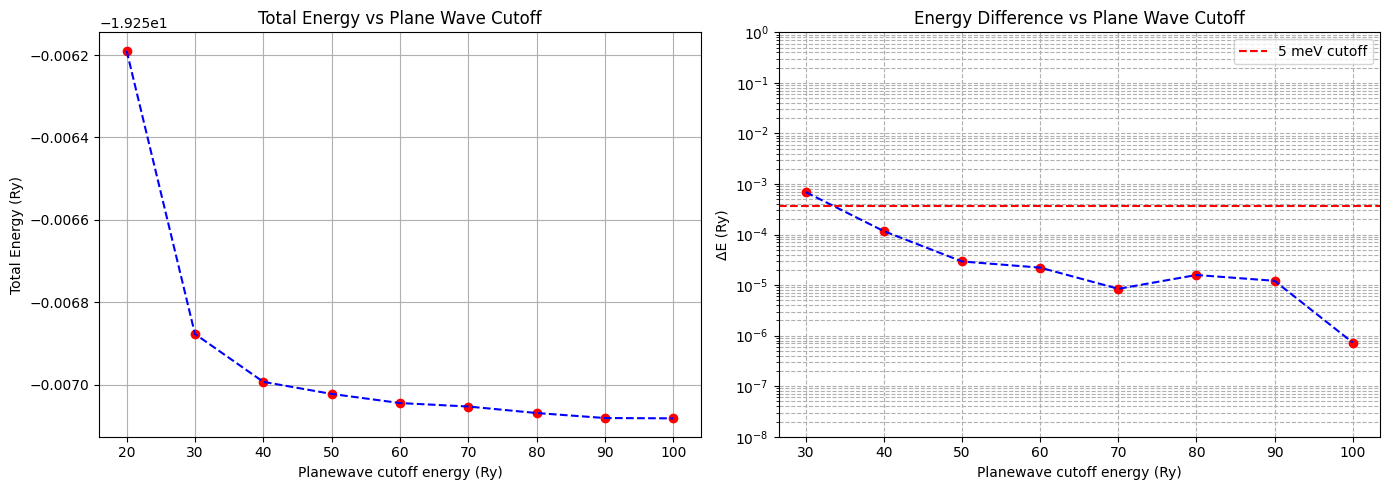

In [48]:
delta_energies = []
for i in range(len(energies)):
    if i == 0 or energies[i] is None or energies[i-1] is None:
        delta_energies.append(None)
    else:
        delta_energies.append(abs(energies[i] - energies[i-1]))
print("cutoffs:", len(cutoffs), cutoffs)
print("energies:", len(energies), energies)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(cutoffs, energies, 'ro')
axes[0].plot(cutoffs, energies, linestyle='--', color='blue')
axes[0].set_xlabel("Planewave cutoff energy (Ry)")
axes[0].set_ylabel("Total Energy (Ry)")
axes[0].set_title("Total Energy vs Plane Wave Cutoff")
axes[0].grid(True)

axes[1].plot(cutoffs, delta_energies, 'ro')
axes[1].plot(cutoffs, delta_energies, linestyle='--', color='blue')
axes[1].axhline(5e-3/13.6, color='r', linestyle='--', label="5 meV cutoff")  # Ry to meV by 13.6
axes[1].set_xlabel("Planewave cutoff energy (Ry)")
axes[1].set_ylabel("ΔE (Ry)")
axes[1].set_title("Energy Difference vs Plane Wave Cutoff")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-8, 1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

In [49]:
ks = list(range(2, 13))
energies = []
num_kpoints = []
print(ks)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [50]:
forces = []
force_pattern = re.compile(r"Total force\s*=\s*([0-9.]+)")
kpoint_pattern = re.compile(r"number of k points\s*=\s*(\d+)")

In [51]:
for k in range(2, 13):
    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q1/A_Pre_Cal/kpoints/si_k{k}/Si_k{k}.out"
    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        forces.append(None)
        continue

    content = response.text
    match = force_pattern.search(content)
    if match:
        force = float(match.group(1))
        forces.append(force)
        print(f"K-point {k}: Total force = {force}")
    else:
        print(f"⚠️ No total force found in {url}")
        forces.append(None)

K-point 2: Total force = 0.075165
K-point 3: Total force = 0.063293
K-point 4: Total force = 0.059895
K-point 5: Total force = 0.058633
K-point 6: Total force = 0.058131
K-point 7: Total force = 0.057922
K-point 8: Total force = 0.057831
K-point 9: Total force = 0.05779
K-point 10: Total force = 0.057769
K-point 11: Total force = 0.057759
K-point 12: Total force = 0.057753


[None, 0.011871999999999994, 0.003398000000000005, 0.0012619999999999992, 0.0005019999999999955, 0.00020900000000000085, 9.10000000000008e-05, 4.099999999999937e-05, 2.1000000000000185e-05, 1.0000000000003062e-05, 5.999999999999062e-06]


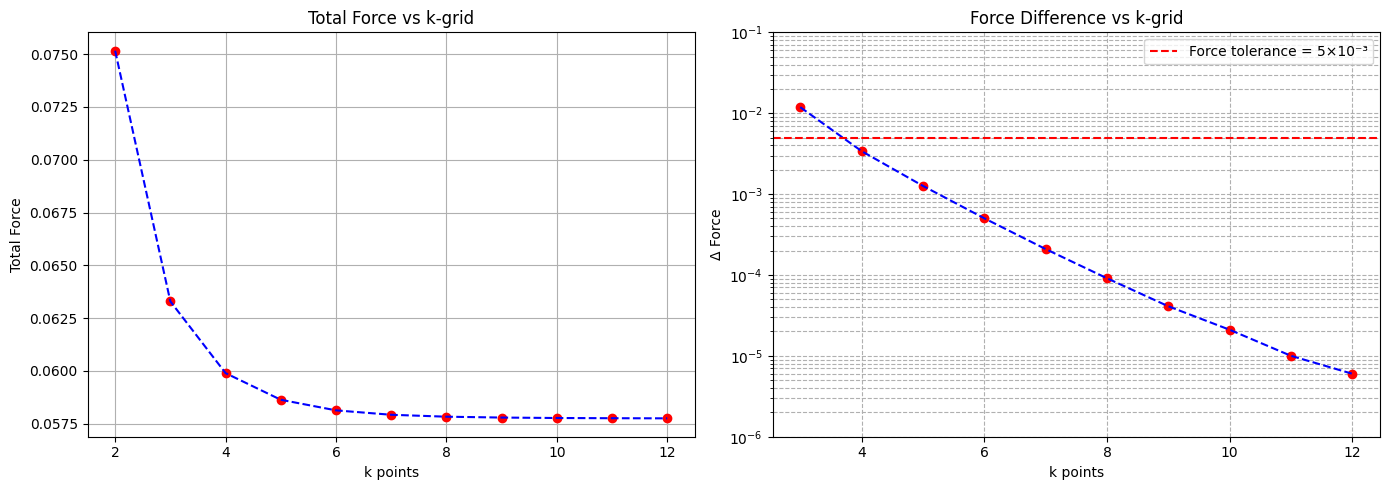

In [52]:
delta_forces = []
for i in range(len(forces)):
    if i == 0 or forces[i] is None or forces[i-1] is None:
        delta_forces.append(None)
    else:
        delta_forces.append(abs(forces[i] - forces[i-1]))

print(delta_forces)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, forces, 'ro')
axes[0].plot(ks, forces, linestyle='--', color='blue')
axes[0].set_xlabel("k points")
axes[0].set_ylabel("Total Force")
axes[0].set_title("Total Force vs k-grid")
axes[0].grid(True)

axes[1].plot(ks, delta_forces, 'ro')
axes[1].plot(ks, delta_forces, linestyle='--', color='blue')
axes[1].axhline(5e-3, color='r', linestyle='--', label="Force tolerance = 5×10⁻³")
axes[1].set_xlabel("k points")
axes[1].set_ylabel("Δ Force")
axes[1].set_title("Force Difference vs k-grid")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-6, 1e-1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

It can be deduced that the converged k point number is 6.

In [53]:
url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q1/bands/bands/Si.bandsplot.gnu"
response = requests.get(url)
if response.status_code != 200:
    raise RuntimeError(f"Failed to fetch data: {url}")

content = response.text.strip()

bands_raw = content.split("\n\n")

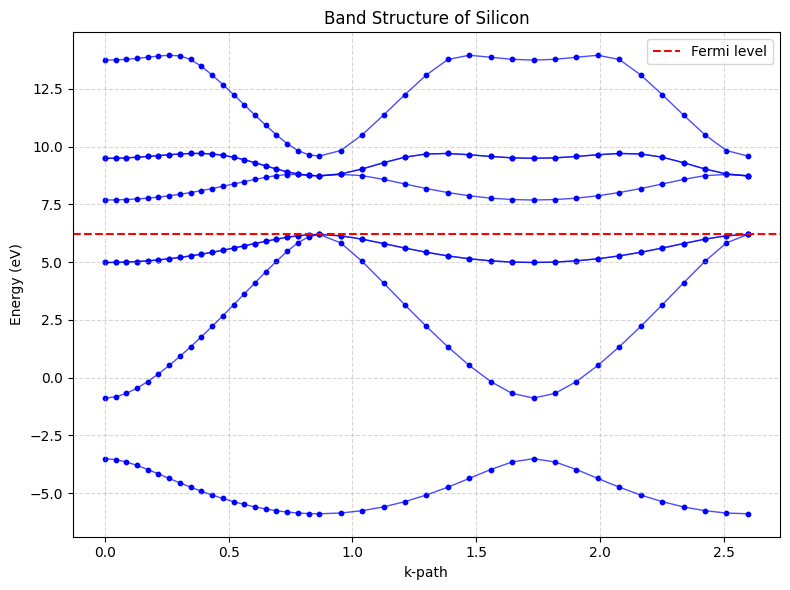

In [54]:
bands = []
for band in bands_raw:
    data = np.loadtxt(band.splitlines())
    k = data[:, 0]
    e = data[:, 1]
    bands.append((k, e))

plt.figure(figsize=(8, 6))

def find_breaks(k_paths):
    breaks = []
    for i in range(1, len(k_paths[0])):
        if abs(k_paths[0][i] - k_paths[0][i-1]) > 0.1:
            breaks.append(i)
    return breaks

breaks = find_breaks([k for k, e in bands])

for k, e in bands:
    start_idx = 0
    for break_idx in breaks:
        end_idx = break_idx
        plt.scatter(k[start_idx:end_idx], e[start_idx:end_idx], s=10, color='blue')
        plt.plot(k[start_idx:end_idx], e[start_idx:end_idx], color='blue', linewidth=1, alpha=0.7)
        start_idx = end_idx
    
    # 绘制最后一段
    plt.scatter(k[start_idx:], e[start_idx:], s=10, color='blue')
    plt.plot(k[start_idx:], e[start_idx:], color='blue', linewidth=1, alpha=0.7)

plt.axhline(6.2002, color='red', linestyle='--', label='Fermi level')

plt.xlabel("k-path")
plt.ylabel("Energy (eV)")
plt.title("Band Structure of Silicon")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

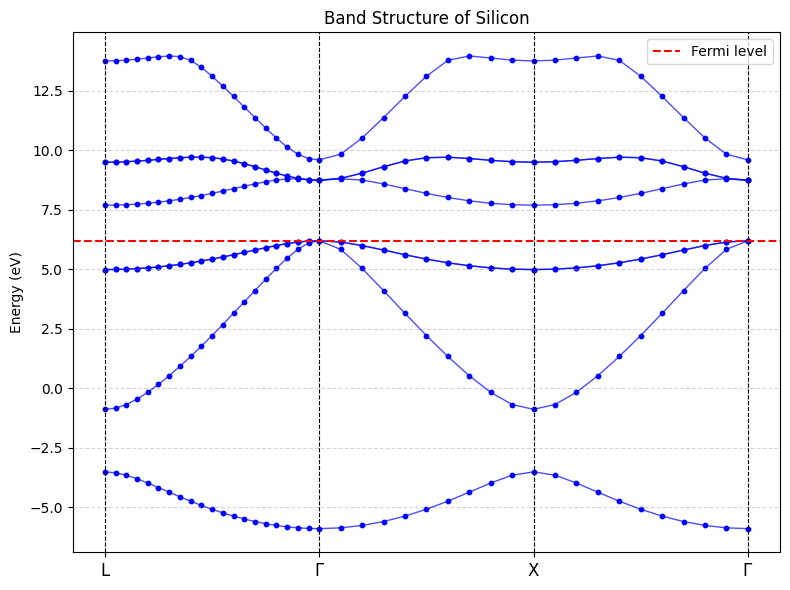

In [55]:
bands = []
for band in bands_raw:
    data = np.loadtxt(band.splitlines())
    k = data[:, 0]
    e = data[:, 1]
    bands.append((k, e))

plt.figure(figsize=(8, 6))

def find_breaks(k_paths):
    breaks = []
    for i in range(1, len(k_paths[0])):
        if abs(k_paths[0][i] - k_paths[0][i-1]) > 0.1:
            breaks.append(i)
    return breaks

breaks = find_breaks([k for k, e in bands])

for k, e in bands:
    start_idx = 0
    for break_idx in breaks:
        end_idx = break_idx
        plt.scatter(k[start_idx:end_idx], e[start_idx:end_idx], s=10, color='blue')
        plt.plot(k[start_idx:end_idx], e[start_idx:end_idx], color='blue', linewidth=1, alpha=0.7)
        start_idx = end_idx

    plt.scatter(k[start_idx:], e[start_idx:], s=10, color='blue')
    plt.plot(k[start_idx:], e[start_idx:], color='blue', linewidth=1, alpha=0.7)

plt.axhline(6.2002, color='red', linestyle='--', label='Fermi level')

high_sym_points = [0, 0.86603, 1.73206, 2.5981]  # k轴位置
labels = ['L', r'$\Gamma$', 'X', r'$\Gamma$']

for x in high_sym_points:
    plt.axvline(x, color='black', linestyle='--', linewidth=0.8)

plt.xticks(high_sym_points, labels, fontsize=12)

plt.xlabel('')
plt.ylabel("Energy (eV)")
plt.title("Band Structure of Silicon")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [56]:
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q1/bands/bands/si_pdos.txt"
filename = "si_pdos.txt"
urllib.request.urlretrieve(url, filename)

data = np.loadtxt(filename, skiprows=1)

E = data[:,0]         
dos_total = data[:,1] 
ldos1 = data[:,2]     
ldos2 = data[:,3]    

E_fermi = 6.22
E_shifted = E - E_fermi

plt.figure(figsize=(6,4))
plt.plot(E_shifted, dos_total, label='Total', color='blue')
plt.plot(E_shifted, ldos1, label='s-orbital', color='red', linestyle='--')
plt.plot(E_shifted, ldos2, label='p-orbital', color='green', linestyle=':')
plt.axvline(0, color='k', linestyle=':', label='Fermi level')  # 标出费米能级
plt.xlabel("Energy - E_fermi (eV)")
plt.ylabel("DOS")
plt.title("Si PDOS")
plt.xlim(-5, 5)
plt.legend()
plt.tight_layout()
plt.show()


IndexError: index 2 is out of bounds for axis 1 with size 2